# Chương 1. Tổng quan về Logic mờ và Ứng dụng

## 3. Tập hợp mờ (Fuzzy Logic)

### Ví dụ 1:
* Giả sử khi cần quản lý về tuổi để phân biệt **người trẻ tuổi**, **người trung niên** và **người già**.

* Ta sử dụng 3 tập tương ứng:
  **A:** trẻ, **B:** trung niên, **C:** già.

* **A, B, C** được gọi là 3 **tập mờ** khi tìm được 3 **hàm thuộc**
  tương ứng là μₐ, μ_b, μ_c.

* Giả sử **không gian nền** là
  **X = {1, 14, 25, 40, 60, 100}**, và quy ước rằng:

  * Người **trẻ tuổi** khi tuổi của họ xung quanh **25**.
  * Người **trung niên** thường có tuổi xấp xỉ **40**.
  * Còn khi **60 tuổi trở lên** có thể coi là **già**.


**Không gian nền**:

X={1,14,25,40,60,100}.

**Chọn ba tập mờ**:

* A – **Trẻ**: {(1,0),(14,0.6),(25,1),(40,0),(60,0),(100,0)}
* B – **Trung niên**: {(1,0),(14,0),(25,0.4),(40,1),(60,0.2),(100,0)}
* C – **Già**: {(1,0),(14,0),(25,0),(40,0.5),(60,1),(100,1)}

$$
A = 
\left\{
\frac{0}{1},
\frac{0.6}{14},
\frac{1}{25},
\frac{0}{40},
\frac{0}{60},
\frac{0}{100}
\right\}, \qquad
B =
\left\{
\frac{0}{1},
\frac{0}{14},
\frac{0.4}{25},
\frac{1}{40},
\frac{0.2}{60},
\frac{0}{100}
\right\}, \qquad

C =
\left\{
\frac{0}{1},
\frac{0}{14},
\frac{0}{25},
\frac{0.5}{40},
\frac{1}{60},
\frac{1}{100}
\right\}.
$$

**Bảng tổng hợp ($\mu_A$,$\mu_B$,$\mu_C$)**:

| x   | $\mu_A$ | $\mu_B$ | $\mu_C$ | Nhãn “hợp nhất” (argmax) |
| --- | --- | --- | --- | ------------------------ |
| 1   | 0   | 0   | 0   | — (không xác định)       |
| 14  | 0.6 | 0   | 0   | Trẻ                      |
| 25  | 1   | 0.4 | 0   | Trẻ                      |
| 40  | 0   | 1   | 0.5 | Trung niên               |
| 60  | 0   | 0.2 | 1   | Già                      |
| 100 | 0   | 0   | 1   | Già                      |


+ “Hợp nhất” ở đây là chọn nhãn có độ thuộc lớn nhất (nếu hòa, có thể cho “không xác định” hoặc áp dụng quy tắc ưu tiên).

**Diễn giải**:
* “Trẻ” tập trung quanh 25 nên điểm 25 có ($\mu_A=1$), còn 14 vẫn được xem là **khá trẻ** (0.6).
* “Trung niên” đỉnh ở 40 ($\mu_B=1$), nhưng 25 vẫn có mức **hơi trung niên** (0.4).
* “Già” đạt mức 1 từ 60 trở lên; tại 40 đã có mức **nửa-già** (0.5).


In [1]:
%pip install numpy matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


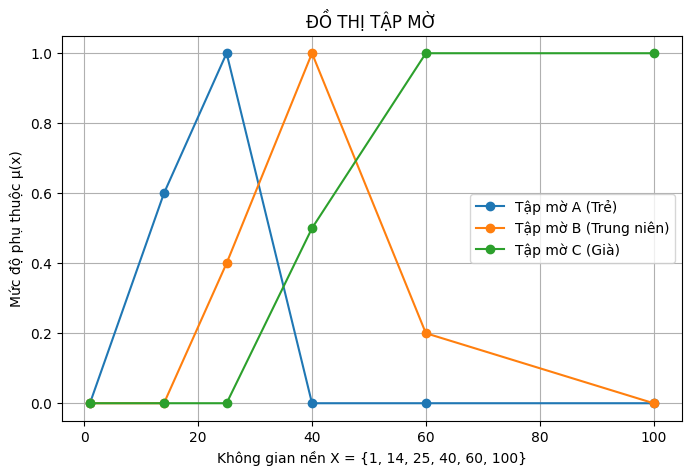

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Không gian nền
X = np.array([1, 14, 25, 40, 60, 100])

# Hàm thuộc theo bảng trong slide
mu_A = np.array([0, 0.6, 1, 0, 0, 0])   # Trẻ
mu_B = np.array([0, 0, 0.4, 1, 0.2, 0]) # Trung niên
mu_C = np.array([0, 0, 0, 0.5, 1, 1])   # Già

# Vẽ đồ thị
plt.figure(figsize=(8,5))
plt.plot(X, mu_A, marker='o', label='Tập mờ A (Trẻ)')
plt.plot(X, mu_B, marker='o', label='Tập mờ B (Trung niên)')
plt.plot(X, mu_C, marker='o', label='Tập mờ C (Già)')

plt.title("ĐỒ THỊ TẬP MỜ")
plt.xlabel("Không gian nền X = {1, 14, 25, 40, 60, 100}")
plt.ylabel("Mức độ phụ thuộc μ(x)")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(True)
plt.show()


### Ví dụ 2:

* Trường hợp không gian nền là một tập hợp vô hạn không đếm được, thì **hàm thành viên** có thể biểu diễn bằng **một biểu thức**.

  * Chẳng hạn, với không gian nền **X** là độ tuổi được tính rất chi ly.
  * Khi đó, **hàm thành viên** của tập mờ tuổi trẻ **A** có thể nội suy các giá trị tại những điểm rời rạc nêu trên để trở thành **một hàm liên tục**.

* Để xấp xỉ các giá trị của **μₐ(x)**, với mọi
  
  $x ∈ [1,14], [14,25], [25,40], [40,100]$,
  
  ta có thể **nội suy tuyến tính** bằng một **đường thẳng** đi qua hai điểm.

* Giả sử hai điểm có tọa độ là **(xₚ, yₚ)** và **(x_Q, y_Q)**.

* Phương trình đường thẳng qua hai điểm:
$$
y = y_P + (y_Q - y_P) \frac{x - x_P}{x_Q - x_P}
$$


Viết **hàm thuộc liên tục** bằng nội suy tuyến tính qua các điểm đã cho. Kí hiệu công thức chung cho đường thẳng qua hai điểm $P(x_P,y_P)$, $Q(x_Q,y_Q)$:
$$
y(x)=y_P+,(y_Q-y_P),\frac{x-x_P}{x_Q-x_P}.
$$

**1.Tập mờ $A$ – “Trẻ”**

Các mốc: $(1,0) \to (14,0.6) \to (25,1) \to(40,0)$.

$$
\mu_A(x)=
\begin{cases}
0, & x\le 1, \\
\dfrac{0.6}{13}(x-1), & x\in[1,14),\\
0.6+\dfrac{1-0.6}{25-14}(x-14)=\dfrac{0.4}{11}x+\dfrac{1}{11}, & x\in[14,25), \\
1+\dfrac{0-1}{40-25}(x-25)=\dfrac{40-x}{15}, & x\in[25,40), \\
0, & x\in[40,100), \\
0, & x\ge 100. \\
\end{cases}
$$

**2.Tập mờ $B$ – “Trung niên”**

Các mốc: $(1,0) \to (14,0) \to (25,0.4) \to (40,1) \to (60,0.2) \to(100,0)$.

$$
\mu_B(x)=
\begin{cases}
0, & x\le 14, \\
\dfrac{0.4-0}{25-14}(x-14)=\dfrac{0.4}{11}(x-14), & x\in[14,25), \\
0.4+\dfrac{1-0.4}{40-25}(x-25)=0.4+\dfrac{1}{25}(x-25), & x\in[25,40),\\
1+\dfrac{0.2-1}{60-40}(x-40)=1-\dfrac{1}{25}(x-40), & x\in[40,60),\\
0.2+\dfrac{0-0.2}{100-60}(x-60)=0.2-\dfrac{1}{200}(x-60), & x\in[60,100),\\
0, & x\ge 100.\\
\end{cases}
$$

**3.Tập mờ $C$ – “Già”**

Các mốc: $(1,0) \to (14,0) \to (25,0) \to (40,0.5) \to(60,1) \to(100,1)$.

$$
\mu_C(x)=
\begin{cases}
0, & x\le 25,\\
\dfrac{0.5-0}{40-25}(x-25)=\dfrac{1}{30}(x-25), & x\in[25,40),\\
0.5+\dfrac{1-0.5}{60-40}(x-40)=0.5+\dfrac{1}{40}(x-40), & x\in[40,60),\\
1, & x\in[60,100),\\
1, & x\ge 100.
\end{cases}
$$

+ Các hàm trên đều là **nội suy tuyến tính** giữa các điểm mốc nên liên tục theo từng đoạn.

+ Có thể dùng để tính $\alpha-cut$, vẽ đồ thị, hay làm mờ / giải mờ.
